---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 04 Segmentação Semântica com U-Net

Este notebook mostra como realizar segmentação de imagens com uma rede U-Net, utilizando imagens sintéticas simples (formas geométricas). 

**Objetivos:**
- Gerar imagens e máscaras sintéticas
- Construir uma U-Net simples
- Treinar com `BCEWithLogitsLoss`
- Visualizar predições por pixel


## 1. Importação das bibliotecas e preparação do ambiente

Esta célula inicial reúne todas as bibliotecas necessárias para a implementação de um modelo de **segmentação de imagens** baseado em redes convolucionais, neste caso com uma arquitetura do tipo *U-Net*.

1. **Bibliotecas do PyTorch:**  
   - `torch` é o núcleo da framework, responsável pelos tensores, operações matemáticas e treino dos modelos.  
   - `torch.nn` e `torch.nn.functional` fornecem as camadas e funções utilizadas na definição da rede neural (como convoluções, ativações e *upsampling*).  

2. **Manipulação de dados e transformações:**  
   - `torchvision.transforms` permite aplicar operações de pré-processamento às imagens (redimensionamento, normalização, conversão para tensor, etc.).  
   - `torch.utils.data.Dataset` e `DataLoader` são usados para criar e iterar sobre conjuntos de dados personalizados, essenciais em tarefas de segmentação onde as imagens e as máscaras associadas devem ser carregadas em pares.

3. **Manipulação e geração de imagens:**  
   - `PIL.Image` e `ImageDraw` permitem criar e editar imagens, útil quando se geram máscaras sintéticas.  
   - `numpy` é usado para manipular arrays numéricos e realizar operações matriciais complementares às do PyTorch.

4. **Visualização e acompanhamento:**  
   - `matplotlib.pyplot` serve para inspecionar imagens, máscaras e resultados da segmentação.  
   - `tqdm` fornece barras de progresso, facilitando o acompanhamento de ciclos de treino ou geração de dados.

**Nota pedagógica:**  
Esta célula estabelece o ambiente de trabalho completo para tarefas de segmentação.  
Enquanto os notebooks anteriores exploravam **classificação de imagens** (prever uma etiqueta global), aqui o foco desloca-se para **prever uma máscara pixel a pixel**, onde cada pixel pertence a uma classe (por exemplo, “objeto” vs. “fundo”).  
As mesmas bibliotecas do PyTorch continuam a ser usadas, mas combinadas de modo a processar simultaneamente imagens e máscaras, refletindo um pipeline típico de *computer vision* orientado a segmentação.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


## 2. Definição da arquitetura U-Net simplificada

Esta célula implementa uma versão reduzida da **U-Net**, uma arquitetura clássica de segmentação de imagens.  
O modelo é definido como uma subclasse de `nn.Module`, composta por duas partes principais: *encoder* (contrator) e *decoder* (expansor).

1. **Encoder — extração de características:**  
   - O *encoder* aplica convoluções e *pooling* sucessivos para capturar padrões de alto nível na imagem.  
   - `Conv2d(3, 16, 3, padding=1)` processa as três camadas de cor da imagem de entrada (RGB) e produz 16 mapas de características.  
   - `ReLU()` introduz não linearidade, permitindo ao modelo aprender representações complexas.  
   - `MaxPool2d(2)` reduz a resolução espacial pela metade, concentrando a informação.  
   - O segundo bloco (`Conv2d(16, 32, ...)`) repete o processo, extraindo características mais abstratas.  
   - No final desta fase, a imagem está “comprimida” num espaço de menor resolução mas com maior profundidade (mais canais).

2. **Decoder — reconstrução espacial:**  
   - O *decoder* usa camadas de *transposed convolution* (`ConvTranspose2d`) para restaurar gradualmente a resolução original.  
   - `ConvTranspose2d(32, 16, 2, stride=2)` expande a imagem, duplicando a altura e largura.  
   - `ReLU()` mantém a não linearidade.  
   - A camada final `ConvTranspose2d(16, 1, 2, stride=2)` produz uma saída com um canal — a **máscara de segmentação**, onde cada pixel representa a probabilidade de pertencer à classe “objeto”.

3. **Função *forward*:**  
   - Define o fluxo de dados: a entrada passa pelo *encoder* (compressão) e depois pelo *decoder* (reconstrução).  
   - O resultado é um mapa 2D da mesma dimensão que a imagem de entrada, mas com apenas um canal (máscara binária).

**Nota pedagógica:**  
Esta implementação é uma versão **minimalista** da U-Net original, suficiente para fins demonstrativos e para conjuntos de dados simples.  
Modelos U-Net completos incluem:
- mais níveis de profundidade (múltiplos blocos encoder–decoder),  
- e **ligações de atalho** (*skip connections*) entre camadas simétricas, que preservam detalhes espaciais perdidos no *downsampling*.  

Essas ligações em “U” são o que dá nome ao modelo e aumentam significativamente a precisão em tarefas reais de segmentação (por exemplo, em imagens médicas ou satélite).  
Aqui, a estrutura é mantida simples para focar a compreensão dos princípios fundamentais: **compressão, reconstrução e previsão pixel a pixel.**

In [2]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


## 3. Criação de um dataset sintético para segmentação

Esta célula define uma classe `SyntheticShapesDataset`, responsável por gerar **imagens sintéticas com formas geométricas simples** (retângulos e elipses) e as respetivas **máscaras de segmentação**.  
O objetivo é dispor de um conjunto de dados totalmente controlado e leve, ideal para demonstrar o funcionamento da U-Net sem depender de datasets externos.

1. **Inicialização:**  
   - `size`: dimensão (altura e largura) das imagens geradas, em píxeis (por defeito 64×64).  
   - `length`: número total de amostras no dataset.  
   - `transform`: transformações opcionais aplicadas às imagens e máscaras (por exemplo, `ToTensor()`).

2. **Métodos principais:**  
   - `__len__`: devolve o número total de amostras disponíveis.  
   - `__getitem__(idx)`: gera uma nova amostra de imagem e máscara, de forma independente.

3. **Geração das imagens e máscaras:**  
   - Cria-se uma imagem RGB de fundo preto (`Image.new('RGB', ...)`) e uma máscara monocromática (`'L'` para *luminance*).  
   - É escolhido aleatoriamente o tipo de forma a desenhar (`rectangle` ou `ellipse`).  
   - As coordenadas do retângulo delimitador (`bbox`) são sorteadas aleatoriamente, garantindo que a forma não sai dos limites da imagem.  
   - A forma é desenhada na imagem colorida com uma cor aleatória e na máscara a branco (`fill=255`) para marcar a área da forma.

4. **Aplicação de transformações:**  
   - Se `transform` estiver definido, é aplicado tanto à imagem como à máscara.  
   - Normalmente, usa-se `transforms.ToTensor()` para converter ambas em tensores PyTorch, facilitando o treino da rede.

5. **Saída:**  
   - Cada amostra devolvida é um par `(imagem, máscara)`, onde:
     - a **imagem** contém uma forma colorida sobre fundo preto;  
     - a **máscara** indica, em branco, a área correspondente à forma (classe “objeto”).

**Nota pedagógica:**  
Este dataset sintético permite **compreender a lógica da segmentação sem ruído nem ambiguidade**.  
Como as formas são simples e os contornos bem definidos, é possível treinar a U-Net rapidamente e observar visualmente se o modelo aprendeu a separar “objeto” e “fundo”.  
Trata-se de uma abordagem didática clássica para introduzir segmentação antes de passar para imagens reais — ideal para testar arquiteturas, funções de perda e métricas de avaliação de forma controlada.

In [3]:
class SyntheticShapesDataset(Dataset):
    def __init__(self, size=64, length=100, transform=None):
        self.size = size
        self.length = length
        self.transform = transform

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        image = Image.new('RGB', (self.size, self.size), 'black')
        mask = Image.new('L', (self.size, self.size), 0)
        draw_image = ImageDraw.Draw(image)
        draw_mask = ImageDraw.Draw(mask)

        shape_type = np.random.choice(['rectangle', 'ellipse'])
        x0, y0 = np.random.randint(5, self.size//2, size=2)
        x1, y1 = np.random.randint(self.size//2, self.size-5, size=2)
        bbox = [x0, y0, x1, y1]
        color = tuple(np.random.randint(128, 256, size=3))

        if shape_type == 'rectangle':
            draw_image.rectangle(bbox, fill=color)
            draw_mask.rectangle(bbox, fill=255)
        else:
            draw_image.ellipse(bbox, fill=color)
            draw_mask.ellipse(bbox, fill=255)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask


## 4. Criação dos conjuntos de treino e teste com o dataset sintético

Esta célula prepara os conjuntos de treino e teste a partir do dataset `SyntheticShapesDataset`, aplicando as transformações adequadas e organizando os dados em *DataLoaders* para utilização na U-Net.

1. **Definição das transformações:**  
   - `transforms.Resize((64, 64))` assegura que todas as imagens e máscaras têm tamanho fixo, compatível com a arquitetura da rede.  
   - `transforms.ToTensor()` converte ambas para tensores PyTorch, normalizando automaticamente os valores de píxel para o intervalo `[0, 1]`.

2. **Conjunto de treino (`train_dataset`):**  
   - Gera 200 imagens sintéticas (`length=200`), cada uma com uma forma aleatória (retângulo ou elipse).  
   - O parâmetro `transform=transform` aplica as transformações definidas acima.  
   - O *DataLoader* correspondente (`train_loader`) divide o conjunto em *batches* de 8 imagens (`batch_size=8`) e baralha a ordem das amostras (`shuffle=True`) a cada época.

3. **Conjunto de teste (`test_dataset`):**  
   - Cria um pequeno conjunto de 8 amostras (`length=8`), útil para inspecionar visualmente os resultados da segmentação.  
   - O *DataLoader* (`test_loader`) usa `batch_size=1` e `shuffle=False` para manter a ordem e facilitar a comparação direta entre previsões e máscaras.

**Nota pedagógica:**  
Mesmo sendo gerado de forma aleatória, este dataset sintético cumpre todas as etapas típicas de preparação de dados reais:  
- definição de transformações,  
- criação de conjuntos de treino e teste,  
- e organização em *DataLoaders* para treino em lotes.  

O tamanho reduzido das imagens (64×64) e do conjunto de treino permite que a U-Net aprenda rapidamente, facilitando a experimentação em ambiente educacional.  
Além disso, o uso de *batches* pequenos torna mais fácil acompanhar a convergência da perda durante o treino, observando como a rede passa de previsões ruidosas para máscaras precisas.

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = SyntheticShapesDataset(size=64, length=200, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

test_dataset = SyntheticShapesDataset(size=64, length=8, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


## 5. Treino da U-Net no conjunto sintético

Esta célula implementa o ciclo completo de treino da rede U-Net sobre o dataset sintético de formas geométricas.  
O objetivo é fazer com que o modelo aprenda a **gerar máscaras binárias** que separem a forma (objeto) do fundo.

1. **Configuração do ambiente e do modelo:**  
   - `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")` permite usar GPU se disponível, acelerando o treino.  
   - O modelo é instanciado com `UNet()` e movido para o dispositivo (`.to(device)`).  
   - O otimizador `Adam` ajusta os pesos da rede com uma taxa de aprendizagem de `0.001`.  
   - A função de perda escolhida é `BCEWithLogitsLoss`, adequada a **segmentação binária**: combina uma camada *sigmoid* implícita com a entropia cruzada binária, medindo o desvio entre as probabilidades previstas e as máscaras reais.

2. **Ciclo de treino:**  
   - O modelo é colocado em modo de treino (`model.train()`).  
   - Para cada época, o *DataLoader* fornece lotes de imagens e máscaras (`images, masks`).  
   - As máscaras são convertidas para `float()` porque a função de perda espera valores contínuos (entre 0 e 1).  
   - O gradiente é limpo (`optimizer.zero_grad()`), a previsão é obtida (`outputs = model(images)`) e a perda é calculada (`loss = criterion(outputs, masks)`).  
   - `loss.backward()` propaga o erro, e `optimizer.step()` atualiza os pesos do modelo.  
   - A perda média é acumulada e mostrada em tempo real com uma barra de progresso (`tqdm`).

3. **Monitorização:**  
   - No final de cada época, imprime-se a perda média, que deve **diminuir progressivamente** à medida que o modelo aprende a reproduzir as máscaras.  
   - Cada *batch* é processado independentemente, permitindo que o modelo veja exemplos variados ao longo do treino.

**Nota pedagógica:**  
O uso de `BCEWithLogitsLoss` é típico em tarefas de segmentação binária, porque evita problemas numéricos de aplicar manualmente uma função *sigmoid* e depois calcular a entropia cruzada.  
O número de épocas (`epochs = 5`) é intencionalmente pequeno para fins demonstrativos; mais épocas permitiriam convergência mais precisa, mas com maior tempo de treino.  

O tamanho do *batch* e a taxa de aprendizagem podem ser ajustados para estudar o equilíbrio entre **estabilidade** (perda suave) e **velocidade de convergência**.  
Mesmo com um dataset sintético simples, esta célula replica todos os passos do treino de um modelo de segmentação real.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

epochs = 5
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device).float()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(Loss=loss.item())
    print(f"Época {epoch+1} concluída — Loss médio: {epoch_loss / len(train_loader):.4f}")


Época 1/5: 100%|████████████████████| 25/25 [00:00<00:00, 50.87it/s, Loss=0.522]


Época 1 concluída — Loss médio: 0.5500


Época 2/5: 100%|████████████████████| 25/25 [00:00<00:00, 46.38it/s, Loss=0.317]


Época 2 concluída — Loss médio: 0.4246


Época 3/5: 100%|█████████████████████| 25/25 [00:00<00:00, 53.57it/s, Loss=0.11]


Época 3 concluída — Loss médio: 0.1989


Época 4/5: 100%|███████████████████| 25/25 [00:00<00:00, 43.51it/s, Loss=0.0394]


Época 4 concluída — Loss médio: 0.0627


Época 5/5: 100%|███████████████████| 25/25 [00:00<00:00, 59.49it/s, Loss=0.0232]

Época 5 concluída — Loss médio: 0.0310


## 6. Avaliação visual da segmentação — comparação entre imagem, previsão e máscara verdadeira

Esta célula avalia qualitativamente o desempenho da U-Net, mostrando lado a lado a **imagem original**, a **máscara prevista pelo modelo** e a **máscara verdadeira** do dataset sintético.

1. **Modo de avaliação:**  
   - O modelo é colocado em modo de avaliação (`model.eval()`), desativando camadas específicas de treino (como *Dropout*).  
   - O bloco `torch.no_grad()` impede o cálculo de gradientes, tornando o processo mais rápido e poupando memória.

2. **Iteração sobre o conjunto de teste:**  
   - São selecionadas apenas algumas amostras (`num_visualizar = 3`) para visualização.  
   - Cada par `(imagem, máscara)` é carregado do `test_loader` e enviado para o dispositivo (CPU ou GPU).  
   - A rede gera uma saída (`outputs = model(images)`), cujos valores são probabilidades não normalizadas.

3. **Geração das previsões binárias:**  
   - `torch.sigmoid(outputs)` converte os valores para probabilidades no intervalo `[0, 1]`.  
   - `preds = (probs > 0.5).float()` aplica um **limiar de 0.5**:  
     - píxeis com probabilidade superior a 0.5 são classificados como “objeto”;  
     - os restantes como “fundo”.

4. **Visualização:**  
   - Para cada exemplo, são exibidas três imagens lado a lado:  
     - **Imagem original**, com a forma colorida sobre fundo preto.  
     - **Previsão** (máscara gerada pela U-Net).  
     - **Máscara verdadeira** (referência usada no treino).  
   - Todas as imagens são mostradas sem eixos, com títulos descritivos.

**Nota pedagógica:**  
Esta visualização permite **avaliar visualmente a qualidade da segmentação** — a forma prevista deve coincidir com a forma real desenhada na máscara.  
Num treino bem-sucedido, o contorno da previsão torna-se nítido e sobrepõe-se corretamente à forma original.  
Diferenças residuais (bordas suaves, falhas pontuais) são normais em redes pequenas ou após poucas épocas.  

Para análise quantitativa, poderiam ser calculadas métricas como o **IoU (Intersection over Union)** ou o **Dice Coefficient**, que medem o grau de sobreposição entre máscara prevista e verdadeira, fornecendo uma medida objetiva da precisão da segmentação.


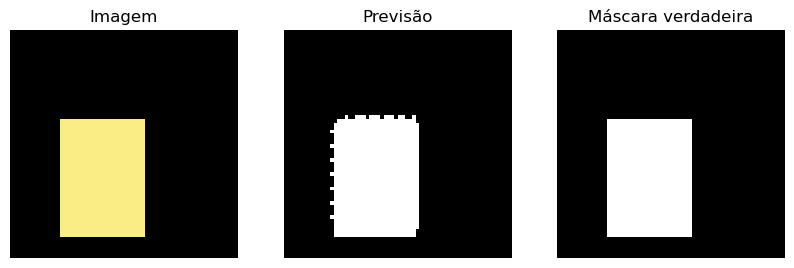

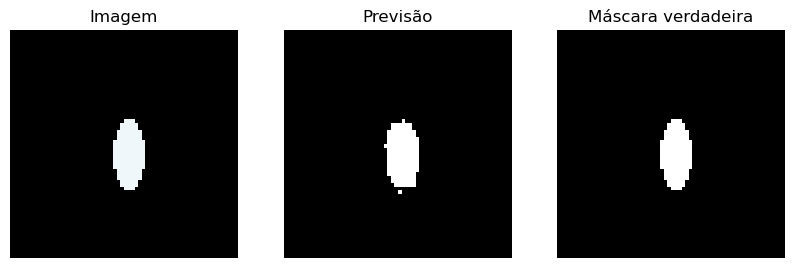

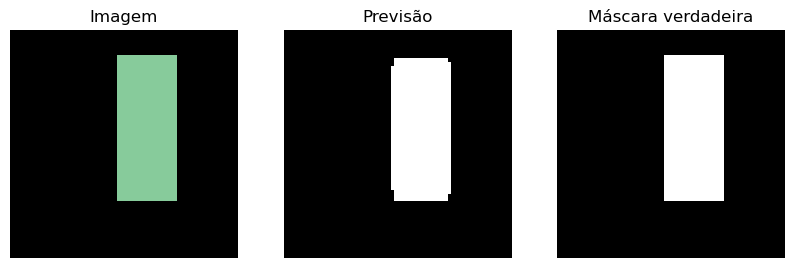

In [6]:
model.eval()
num_visualizar = 3

with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        if i >= num_visualizar:
            break
        images, masks = images.to(device), masks.to(device).float()
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        fig, axs = plt.subplots(1, 3, figsize=(10, 4))
        axs[0].imshow(images[0].permute(1, 2, 0).cpu())
        axs[0].set_title("Imagem")
        axs[1].imshow(preds[0][0].cpu(), cmap='gray')
        axs[1].set_title("Previsão")
        axs[2].imshow(masks[0][0].cpu(), cmap='gray')
        axs[2].set_title("Máscara verdadeira")
        for ax in axs:
            ax.axis('off')
        plt.show()


## 7. U-Net completa com *skip connections*

Esta célula introduz uma versão mais fiel da arquitetura U-Net clássica.  
Inclui camadas de convolução duplas em cada nível e **ligações de atalho (skip connections)** entre encoder e decoder, que preservam detalhes espaciais perdidos durante o *downsampling*.  

O modelo continua leve (três níveis de profundidade), mas segue a lógica estrutural da U-Net original: compressão progressiva de características seguida de reconstrução com fusão de mapas simétricos.  
A camada final de 1×1 gera a máscara binária de segmentação.

In [7]:
class UNetFull(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNetFull, self).__init__()
        
        # Blocos de codificação (downsampling)
        self.enc1 = self.double_conv(in_channels, 64)
        self.enc2 = self.double_conv(64, 128)
        self.enc3 = self.double_conv(128, 256)
        
        # Blocos de decodificação (upsampling)
        self.up2 = self.up_block(256, 128)
        self.dec2 = self.double_conv(256, 128)
        
        self.up1 = self.up_block(128, 64)
        self.dec1 = self.double_conv(128, 64)
        
        # Camada de saída
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def up_block(self, in_ch, out_ch):
        return nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        
        # Decoder com ligações de atalho
        d2 = self.up2(e3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.out_conv(d1)

## 8. Treino multi-época mais profundo da U-Net completa

Nesta fase o modelo é treinado durante várias épocas (15 por defeito), permitindo observar uma melhoria mais gradual e estável da função de perda.  

O otimizador e a função de perda permanecem os mesmos (`Adam`, `BCEWithLogitsLoss`), mas o número de iterações é maior para favorecer a convergência.  
O *tqdm* acompanha o progresso em tempo real, e a perda média por época tende a estabilizar à medida que o modelo se adapta às formas do dataset sintético.

Note-se que para este exemplo a loss function chega a 0.0000 na época 12 e depois sobe ligeiramente... um claro sinal de overfitting.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_full = UNetFull().to(device)

optimizer = torch.optim.Adam(model_full.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

epochs = 15  # mais épocas para observar melhoria gradual
model_full.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device).float()
        optimizer.zero_grad()
        outputs = model_full(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(Loss=f"{loss.item():.4f}")
    print(f"Época {epoch+1} — Loss médio: {epoch_loss / len(train_loader):.4f}")

Época 1/15: 100%|██████████████████| 25/25 [00:11<00:00,  2.19it/s, Loss=0.0144]


Época 1 — Loss médio: 0.1991


Época 2/15: 100%|██████████████████| 25/25 [00:13<00:00,  1.82it/s, Loss=0.0061]


Época 2 — Loss médio: 0.0377


Época 3/15: 100%|██████████████████| 25/25 [00:12<00:00,  1.96it/s, Loss=0.0070]


...

Época 13 — Loss médio: 0.0002


Época 14/15: 100%|█████████████████| 25/25 [05:35<00:00, 13.42s/it, Loss=0.0000]


Época 14 — Loss médio: 0.0001


Época 15/15: 100%|█████████████████| 25/25 [04:19<00:00, 10.40s/it, Loss=0.0001]

Época 15 — Loss médio: 0.0001


## 9. Avaliação visual — comparação com a U-Net simples

Esta célula repete o processo de avaliação, agora com o modelo completo.  
São mostradas lado a lado a **imagem original**, a **previsão do modelo** e a **máscara verdadeira**.  

A inclusão das *skip connections* deve resultar em **bordas mais nítidas e previsões mais fiéis** à forma real, evidenciando a vantagem da arquitetura completa mesmo num dataset artificial simples.

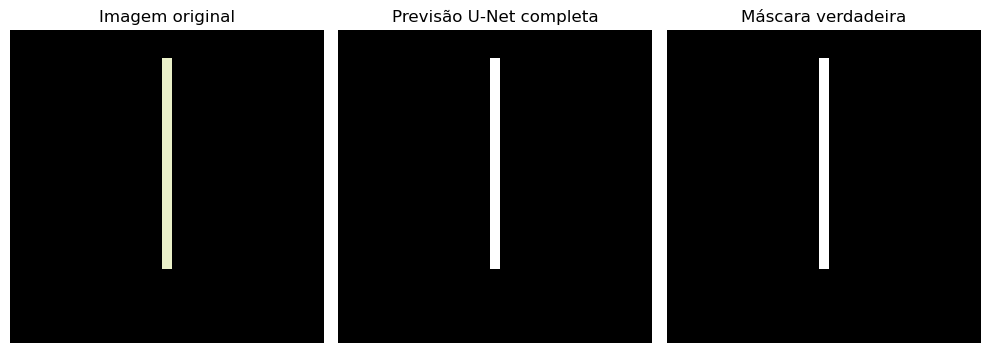

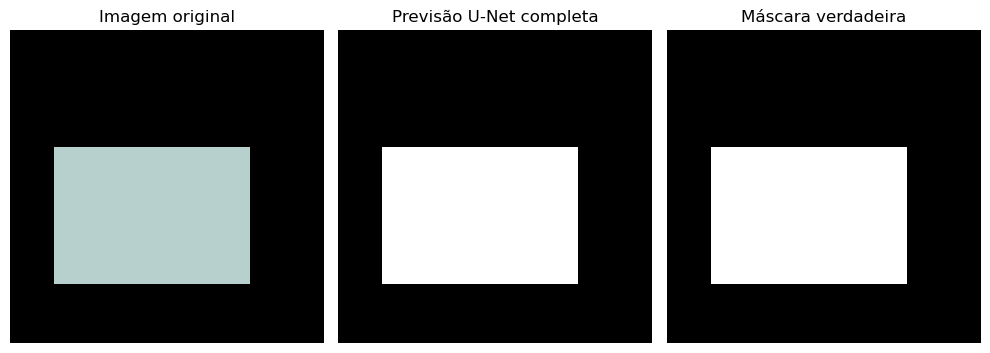

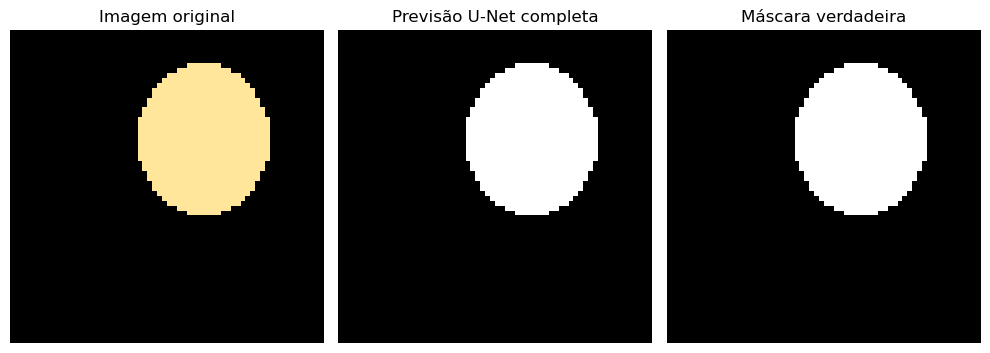

In [9]:
model_full.eval()
num_visualizar = 3

with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        if i >= num_visualizar:
            break
        images, masks = images.to(device), masks.to(device).float()
        outputs = model_full(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        fig, axs = plt.subplots(1, 3, figsize=(10, 4))
        axs[0].imshow(images[0].permute(1, 2, 0).cpu())
        axs[0].set_title("Imagem original")
        axs[1].imshow(preds[0][0].cpu(), cmap='gray')
        axs[1].set_title("Previsão U-Net completa")
        axs[2].imshow(masks[0][0].cpu(), cmap='gray')
        axs[2].set_title("Máscara verdadeira")
        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
        plt.show()